<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTERPOLASI SPASIAL MENGGUNAKAN METODE CO-KRIGING

## Prediksi Temperatur Berdasarkan Variabel Meteorologi Sekunder

Metode Co-Kriging digunakan untuk melakukan estimasi nilai pada lokasi
yang tidak memiliki pengamatan dengan memanfaatkan hubungan spasial
antara variabel utama dan variabel pendukung.

Pada penelitian ini, temperatur udara digunakan sebagai variabel utama,
sedangkan variabel meteorologi lain digunakan sebagai variabel sekunder.

# 2. Import Library
## Persiapan Library

Tahap awal dilakukan dengan mempersiapkan library yang digunakan untuk
pengolahan data, visualisasi, analisis korelasi, variogram, serta pemodelan
Co-Kriging.

In [34]:
!pip install pykrige scikit-gstat -q


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from skgstat import Variogram

from pykrige.uk import UniversalKriging


from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


import warnings
warnings.filterwarnings("ignore")

# 3. Membaca Dataset
## Input Data

Dataset yang digunakan merupakan data observasi stasiun cuaca yang
memiliki informasi lokasi geografis dan parameter meteorologi.

Informasi lokasi berupa latitude dan longitude digunakan sebagai dasar
analisis spasial.

In [36]:
# ==========================================
# UPLOAD DATASET
# ==========================================

from google.colab import files
import pandas as pd


uploaded = files.upload()


# mengambil nama file yang diupload
filename = list(uploaded.keys())[0]


# membaca csv
df = pd.read_csv(filename)


print("File berhasil dibaca:")
print(filename)


print("\nUkuran Data:")
print(df.shape)


df.head()

Saving Data to Data
File berhasil dibaca:
Data

Ukuran Data:
(31, 13)


,StationID,DateTimeUTC,Latitude,Longitude,Temperature_C,Humidity_perc,WindSpeed_kph,WindDirection_deg,Pressure_hPa,Rainfall_mm_last_hr,SolarIrradiance_W_m2,AirQuality_Index,Sensor_Status
0,WS_01A,2025-03-15 10:00:00,34.0522,-118.2437,18.5,45.2,12.5,270,1012.5,0.0,750,55,Operational
1,WS_02B,2025-03-15 10:05:00,40.7128,-74.0060,10.1,68.9,8.2,180,1005.8,0.0,410,88,Operational
2,WS_03C,2025-03-15 10:10:00,51.5074,-0.1278,7.9,85.1,15.7,315,998.1,0.5,150,42,Operational
3,WS_04D,2025-03-15 10:15:00,-33.8688,151.2093,25.4,55.0,20.1,90,1015.0,0.0,920,61,Operational
4,WS_05E,2025-03-15 10:20:00,48.8566,2.3522,12.3,72.4,5.9,45,1010.3,0.0,580,75,Operational


# 4. Pemeriksaan Data
## Pemeriksaan Struktur Data

Tahap ini dilakukan untuk mengetahui jumlah data, tipe variabel,
serta memastikan variabel yang digunakan tersedia dalam dataset.

In [38]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StationID             31 non-null     object 
 1   DateTimeUTC           31 non-null     object 
 2   Latitude              31 non-null     float64
 3   Longitude             31 non-null     float64
 4   Temperature_C         31 non-null     float64
 5   Humidity_perc         31 non-null     float64
 6   WindSpeed_kph         31 non-null     float64
 7   WindDirection_deg     31 non-null     int64  
 8   Pressure_hPa          31 non-null     float64
 9   Rainfall_mm_last_hr   31 non-null     float64
 10  SolarIrradiance_W_m2  31 non-null     int64  
 11  AirQuality_Index      31 non-null     int64  
 12  Sensor_Status         31 non-null     object 
dtypes: float64(7), int64(3), object(3)
memory usage: 3.3+ KB


,Latitude,Longitude,Temperature_C,Humidity_perc,WindSpeed_kph,WindDirection_deg,Pressure_hPa,Rainfall_mm_last_hr,SolarIrradiance_W_m2,AirQuality_Index
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,28.439142,-11.327087,16.125806,61.251613,13.596774,194.032258,1008.735484,0.241935,604.838710,62.258065
std,31.681846,93.803652,6.762592,15.357775,5.319679,104.771333,6.003974,0.551830,275.516133,14.924181
min,-33.868800,-118.243700,7.900000,36.500000,5.900000,45.000000,998.100000,0.000000,150.000000,42.000000
25%,34.052200,-74.006000,10.700000,48.250000,8.650000,97.500000,1005.950000,0.000000,432.500000,50.500000
50%,40.712800,-0.127800,13.200000,64.500000,14.500000,195.000000,1010.600000,0.000000,625.000000,58.000000
75%,48.856600,2.352200,21.200000,70.250000,16.750000,292.500000,1012.950000,0.000000,817.500000,73.500000
max,51.507400,151.209300,28.200000,85.100000,22.500000,330.000000,1015.500000,2.000000,995.000000,88.000000


# 5. Data Cleaning
## Pembersihan Data

Data kosong dapat menyebabkan kesalahan dalam proses analisis.
Oleh karena itu dilakukan penghapusan data yang tidak lengkap.

In [39]:
df = df.dropna()


print(
"Jumlah data:",
len(df)
)

Jumlah data: 31


# 6. Visualisasi Persebaran Lokasi
## Distribusi Spasial Lokasi Pengamatan

Visualisasi lokasi digunakan untuk melihat persebaran titik observasi
berdasarkan koordinat geografis.

Titik-titik tersebut menjadi dasar dalam proses interpolasi spasial.

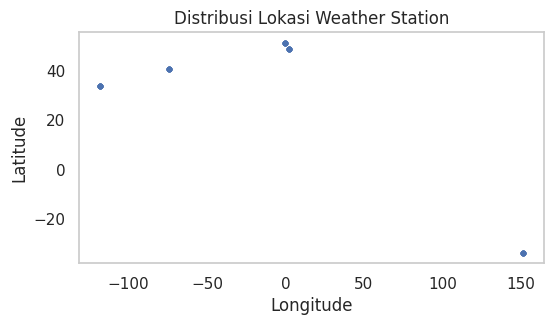

In [42]:
plt.figure(
    figsize=(6,3)
)


plt.scatter(
    df["Longitude"],
    df["Latitude"],
    s=10
)


plt.xlabel("Longitude")

plt.ylabel("Latitude")


plt.title(
"Distribusi Lokasi Weather Station"
)


plt.grid()

plt.show()

# 7. Analisis Korelasi Variabel
## Pemilihan Variabel Sekunder

Pada metode Co-Kriging diperlukan dua variabel:

1. Primary variable:
   Variabel utama yang akan diprediksi.

2. Secondary variable:
   Variabel tambahan yang memiliki hubungan dengan variabel utama.


Korelasi digunakan untuk menentukan variabel sekunder yang paling sesuai.

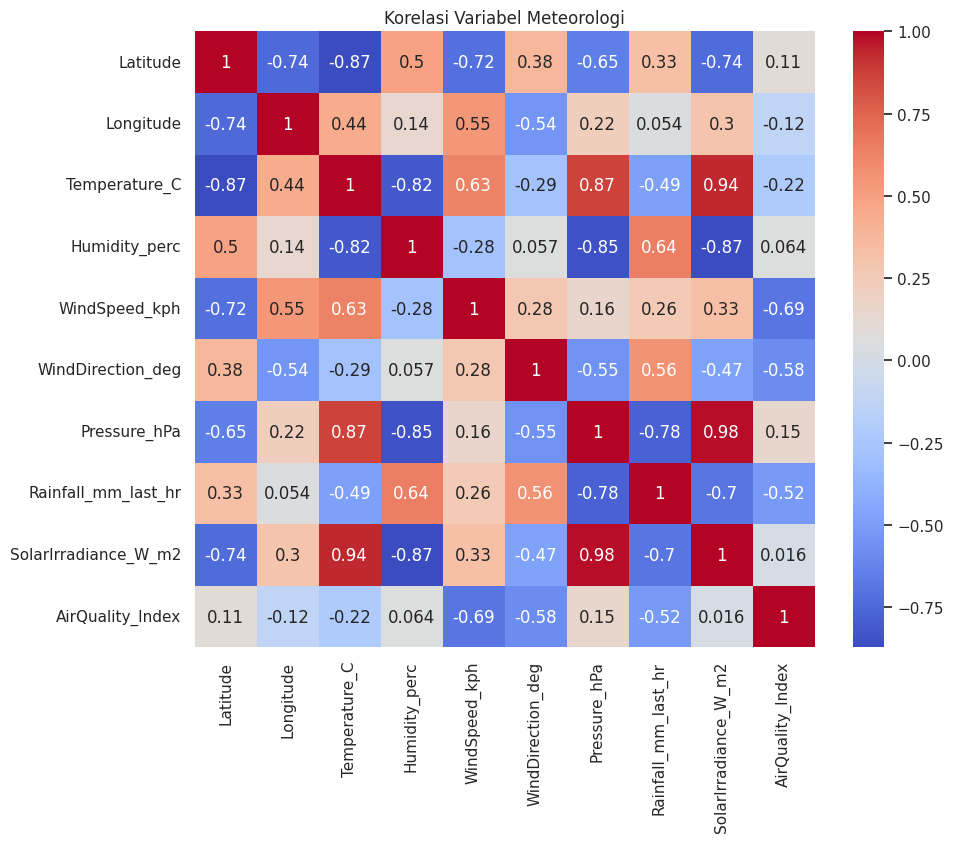

In [43]:
numeric = df.select_dtypes(
    include=np.number
)


corr = numeric.corr()


plt.figure(
    figsize=(10,8)
)


sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)


plt.title(
"Korelasi Variabel Meteorologi"
)


plt.show()

In [44]:
primary = "Temperature_C"


corr_temp = (
    corr[primary]
    .drop(primary)
    .abs()
    .sort_values(
        ascending=False
    )
)


corr_temp

,Temperature_C
SolarIrradiance_W_m2,0.941052
Latitude,0.872343
Pressure_hPa,0.865713
Humidity_perc,0.819944
WindSpeed_kph,0.629962
Rainfall_mm_last_hr,0.486750
Longitude,0.441368
WindDirection_deg,0.286639
AirQuality_Index,0.220956


In [45]:
secondary = corr_temp.index[0]


print(
"Primary Variable:",
primary
)


print(
"Secondary Variable:",
secondary
)

Primary Variable: Temperature_C
Secondary Variable: SolarIrradiance_W_m2


# 8. Variogram Primary Variable
## Analisis Variogram Temperatur

Variogram digunakan untuk mengetahui hubungan antara jarak antar lokasi
dengan tingkat kemiripan nilai temperatur.

Variogram menjadi dasar dalam menentukan struktur spasial sebelum
melakukan interpolasi Co-Kriging.

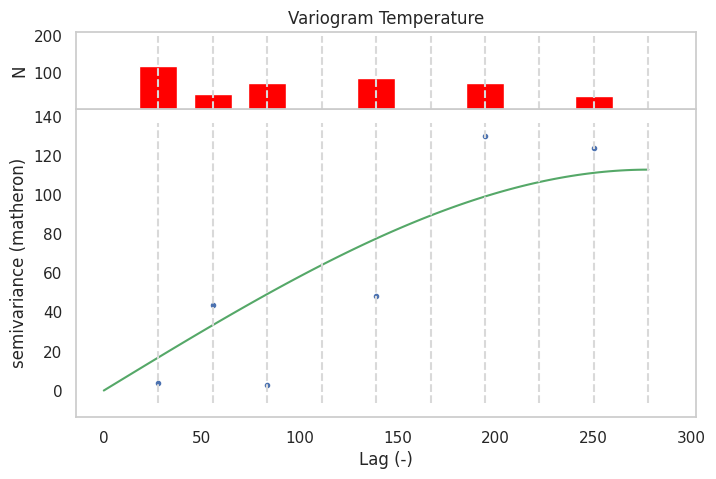

In [46]:
coords = df[
[
"Longitude",
"Latitude"
]
].values



V_primary = Variogram(

coords,

df[primary],

model="spherical"

)


V_primary.plot()


plt.title(
"Variogram Temperature"
)


plt.show()

# 9. Variogram Secondary Variable
## Variogram Variabel Sekunder

Variogram variabel sekunder digunakan untuk mengetahui pola spasial
dari variabel pendukung yang membantu proses estimasi temperatur.

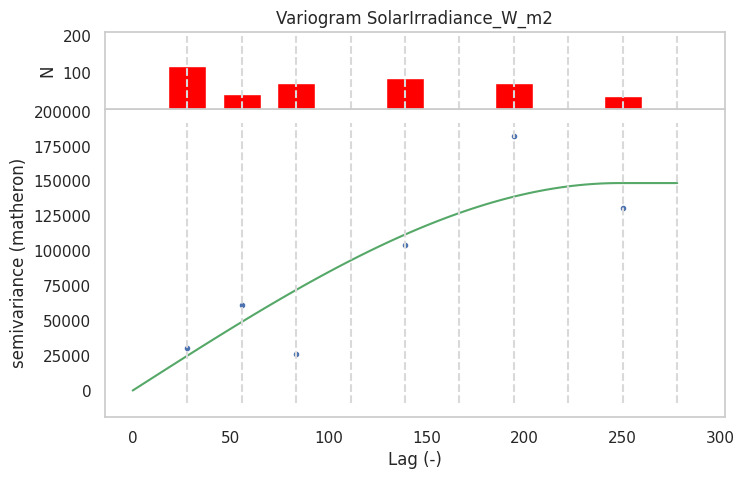

In [47]:
V_secondary = Variogram(

coords,

df[secondary],

model="spherical"

)


V_secondary.plot()


plt.title(
f"Variogram {secondary}"
)


plt.show()

# 10. Cross Variogram / Hubungan Antar Variabel
## Cross Relationship

Cross relationship menunjukkan hubungan antara variabel utama dan
variabel sekunder.

Hubungan yang kuat menunjukkan bahwa variabel sekunder dapat memberikan
informasi tambahan dalam proses Co-Kriging.

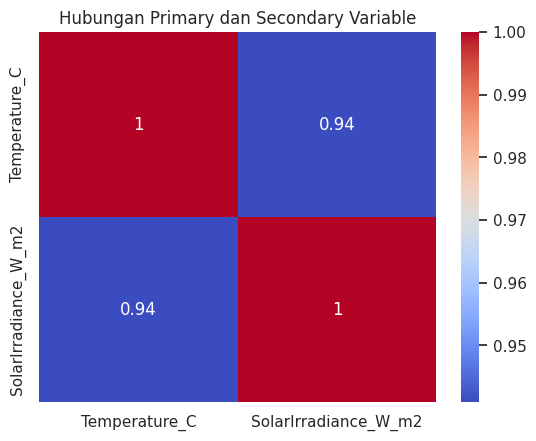

In [48]:
cross = df[
[
primary,
secondary
]
].corr()


sns.heatmap(
cross,
annot=True,
cmap="coolwarm"
)


plt.title(
"Hubungan Primary dan Secondary Variable"
)


plt.show()

# 11. Pemodelan Co-Kriging
## Model Co-Kriging

Co-Kriging merupakan pengembangan metode Kriging yang menggunakan
lebih dari satu variabel.

Pada penelitian ini temperatur diprediksi menggunakan informasi spasial
temperatur dan variabel meteorologi sekunder terpilih.

In [50]:
UK = UniversalKriging(

    df["Longitude"],

    df["Latitude"],

    df[primary],


    variogram_model="spherical",


    drift_terms=["specified"],


    specified_drift=[
        df[secondary]
    ]

)

# 12. Membuat Grid Prediksi
## Prediksi Spasial

Model digunakan untuk memperkirakan temperatur pada lokasi yang tidak
memiliki pengamatan langsung.

Prediksi dilakukan pada area grid berdasarkan rentang koordinat data.

In [51]:
grid_lon = np.linspace(

df.Longitude.min(),

df.Longitude.max(),

100

)


grid_lat = np.linspace(

df.Latitude.min(),

df.Latitude.max(),

100

)

# 13. Hasil Interpolasi Co-Kriging

In [52]:
secondary_grid = np.mean(
df[secondary]
)



prediction, variance = UK.execute(

    "grid",

    grid_lon,

    grid_lat,


    specified_drift_arrays=[

        np.ones(
            (100,100)
        )
        *
        secondary_grid

    ]

)

# 14. Visualisasi Peta Interpolasi
## Peta Hasil Interpolasi

Peta interpolasi menunjukkan distribusi temperatur hasil estimasi
Co-Kriging pada seluruh area pengamatan.

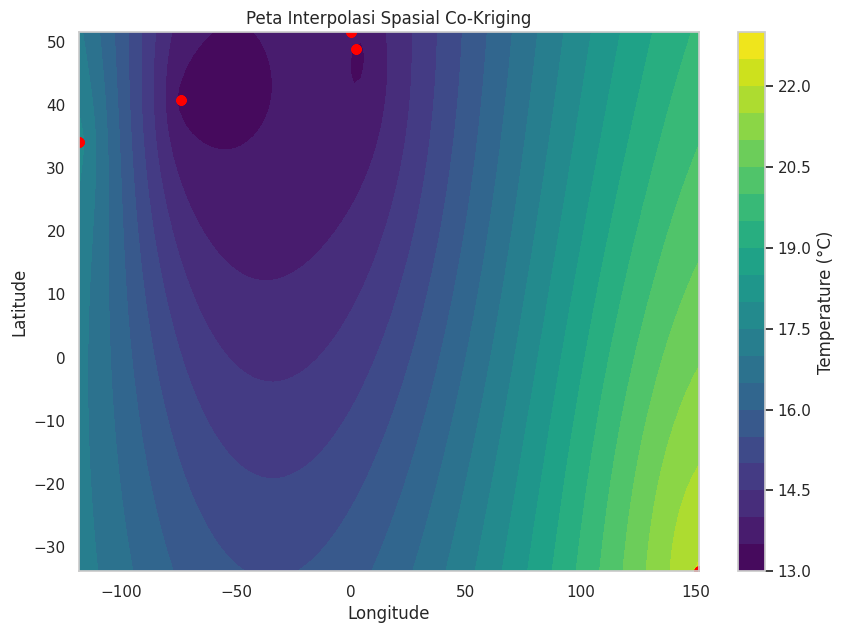

In [53]:
plt.figure(
    figsize=(10,7)
)


plt.contourf(

grid_lon,

grid_lat,

prediction,

levels=20,

cmap="viridis"

)


plt.colorbar(
label="Temperature (°C)"
)


plt.scatter(

df.Longitude,

df.Latitude,

c="red",

s=40

)


plt.xlabel(
"Longitude"
)


plt.ylabel(
"Latitude"
)


plt.title(
"Peta Interpolasi Spasial Co-Kriging"
)


plt.show()

# 15. Evaluasi Model
## Evaluasi Akurasi Model

Evaluasi dilakukan menggunakan:

- RMSE:
  Mengukur rata-rata kesalahan prediksi.

- MAE:
  Mengukur rata-rata selisih absolut prediksi.

- R²:
  Menunjukkan kemampuan model menjelaskan variasi data.

In [55]:
# ==========================================
# EVALUASI MODEL CO-KRIGING
# ==========================================


pred_point, variance = UK.execute(

    "points",

    df["Longitude"].values,

    df["Latitude"].values,


    specified_drift_arrays=[

        df[secondary].values

    ]

)



rmse = np.sqrt(

    mean_squared_error(

        df[primary],

        pred_point

    )

)


mae = mean_absolute_error(

    df[primary],

    pred_point

)


r2 = r2_score(

    df[primary],

    pred_point

)



print("RMSE :", rmse)

print("MAE  :", mae)

print("R²   :", r2)

RMSE : 1.4908079040411641
MAE  : 1.306973412415826
R²   : 0.9497822221840944
